<a href="https://colab.research.google.com/github/h1baq1m/skills-getting-started-with-github-copilot/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


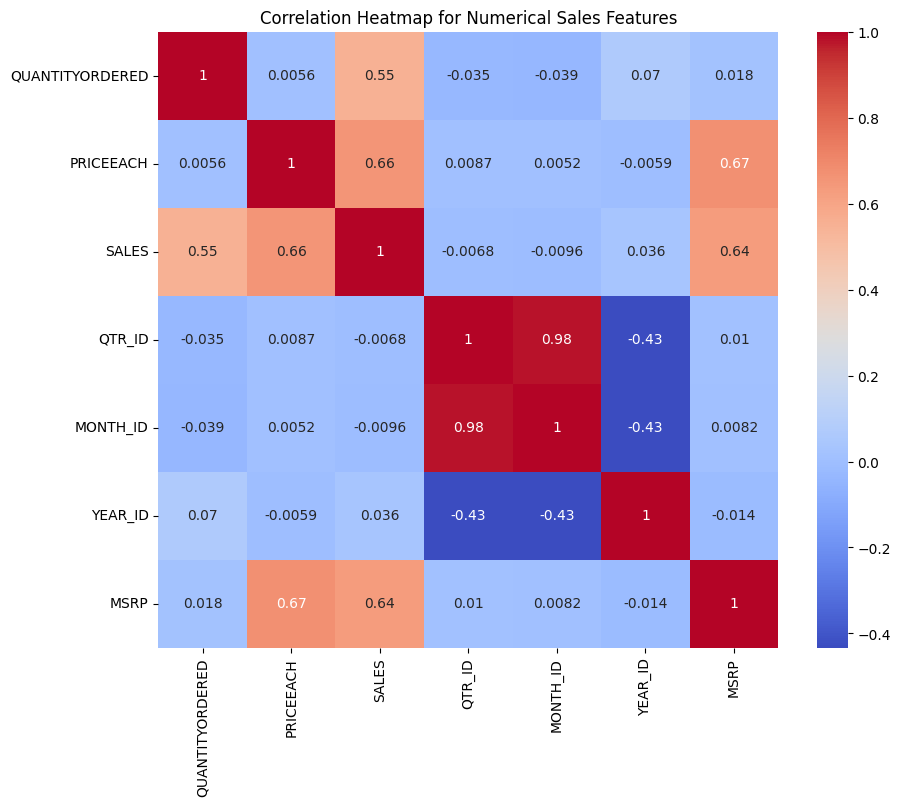

Explained variance ratio: [0.3423053  0.32502752]


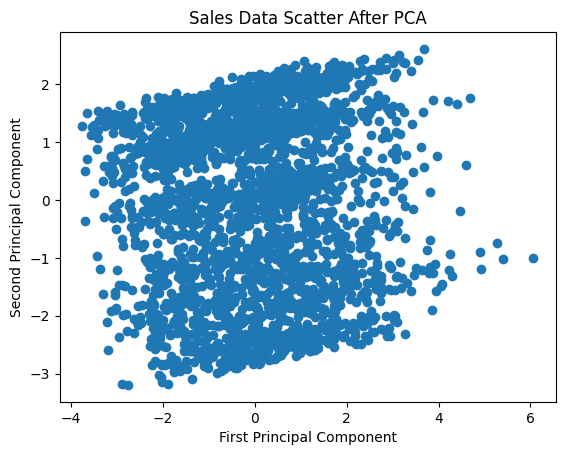

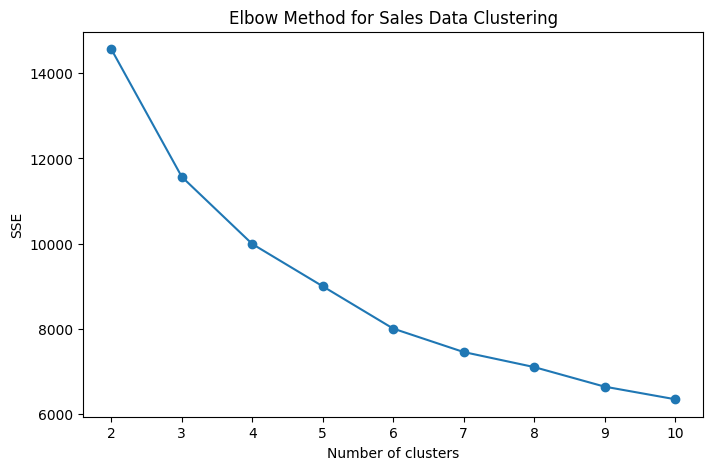

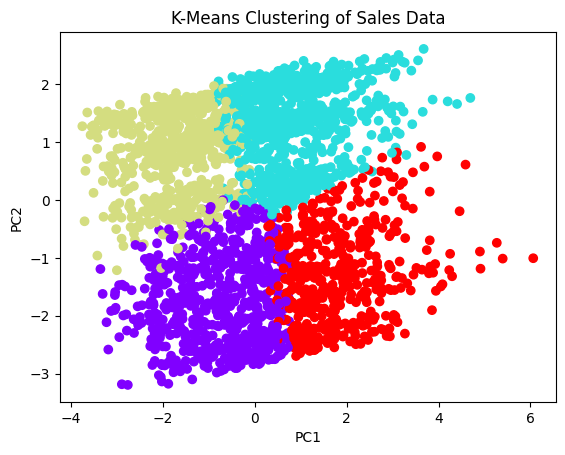

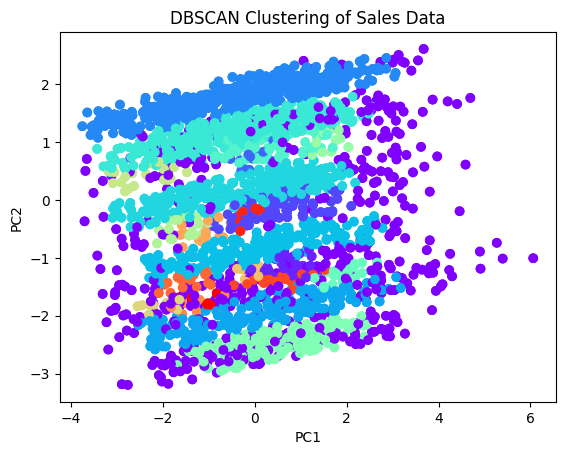

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#upload the sales dataset and display first 5 records and add in encoding due to some non-UTF-8 characters in dataset

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")
df.head()

#discovers the dataytype, record number and column name for the dataframe

print(df.info())

#check for any missing values

print(df.isnull().sum())

#checks the basic stats for the numerical columns

df.describe()

#drops any duplicate records and then see if anything changes in the dataframe

df = df.drop_duplicates()
print(df.info())

#creates a graph that shows the correlation between the numerical sales figures

sales_features = df[[
    "QUANTITYORDERED",
    "PRICEEACH",
    "SALES",
    "QTR_ID",
    "MONTH_ID",
    "YEAR_ID",
    "MSRP"
]]

plt.figure(figsize=(10, 8))
sns.heatmap(sales_features.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Numerical Sales Features")
plt.show()

#creates a scaler and applies it to the sales features.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(sales_features)

scaled_df = pd.DataFrame(scaled_features, columns=sales_features.columns)
scaled_df.describe()

# Implement PCA to reduce the scaled features into a 2-feature dataframe.
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_df = pd.DataFrame(pca.fit_transform(scaled_df), columns=["PC1", "PC2"])

print("Explained variance ratio:", pca.explained_variance_ratio_)
pca_df.head()

#plot the dataframe into a scatter graph

plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("Sales Data Scatter After PCA")
plt.show()

# Use the elbow method to find a suitable number of clusters for K-Means.
from sklearn.cluster import KMeans

sse = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.title("Elbow Method for Sales Data Clustering")
plt.show()

#creates a K-Means model with 4 clusters
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(scaled_df)

#show the K-Means clusters on a scatter graph.

plt.scatter(pca_df["PC1"], pca_df["PC2"], c=kmeans.labels_, cmap="rainbow")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering of Sales Data")
plt.show()

#create a DBSCAN model and plot it on a scatter graph.
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.7, min_samples=10).fit(scaled_df)

plt.scatter(pca_df["PC1"], pca_df["PC2"], c=db.labels_, cmap="rainbow")

plt.scatter(pca_df["PC1"], pca_df["PC2"], c=db.labels_, cmap="rainbow")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering of Sales Data")
plt.show()


